In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

df = pd.read_csv('Reviews_sentiment.csv')
print(df.shape)
print(df.columns.tolist())

(363821, 17)
['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text', 'review_length', 'helpfulness_ratio', 'Year', 'refined_text', 'sentiment', 'vader_score', 'vader_label']


In [2]:
df2= pd.read_csv('Reviews_lemmatized.csv')

# Drop score 3 — same as sentiment phase
df2= df2[df2['Score'] != 3].copy()
df2['sentiment'] = df2['Score'].apply(lambda x: 1 if x >= 4 else 0)
df2['lemmatized_text'] = df2['lemmatized_text'].fillna('')
df2 = df2[df2['lemmatized_text'].str.strip() != '']

print(f"Shape: {df2.shape}")
print(f"Sentiment distribution:\n{df2['sentiment'].value_counts()}")

Shape: (363822, 15)
Sentiment distribution:
sentiment
1    306755
0     57067
Name: count, dtype: int64


In [3]:
import re

def remove_html(text):
    text = str(text)
    text = re.sub(r'<.*?>', ' ', text)           # remove HTML tags
    text = re.sub(r'&amp;|&lt;|&gt;', ' ', text) # remove HTML entities
    text = re.sub(r'\bbr\b', ' ', text)           # remove standalone br
    text = re.sub(r'\s+', ' ', text).strip()      # clean extra spaces
    return text

df2['lemmatized_text'] = df2['lemmatized_text'].apply(remove_html)

# Verify br is gone
sample = df2['lemmatized_text'].iloc[0]
print("Sample:", sample[:200])
print("\nBR count remaining:", df2['lemmatized_text'].str.contains(r'\bbr\b').sum())

Sample: buy vitality dog food product find good quality product look like stew process meat smell well labrador finicky appreciate product well

BR count remaining: 0


In [4]:
vectorizer = CountVectorizer(
    max_features=15000,
    min_df=5,
    max_df=0.90
)

doc_term_matrix = vectorizer.fit_transform(df2['lemmatized_text'])
print(f"Document-Term Matrix shape: {doc_term_matrix.shape}")

Document-Term Matrix shape: (363822, 15000)


In [5]:
lda = LatentDirichletAllocation(
    n_components=8,
    random_state=42,
    learning_method='online',
    batch_size=2048,
    max_iter=5,
    n_jobs=1
)

batch_size = 2048
n_samples = doc_term_matrix.shape[0]

for i, start in enumerate(range(0, n_samples, batch_size)):
    end = min(start + batch_size, n_samples)
    batch = doc_term_matrix[start:end]
    lda.partial_fit(batch)
    if i % 20 == 0:
        print(f"Processed {end}/{n_samples} reviews...")

print("LDA trained successfully!")

Processed 2048/363822 reviews...
Processed 43008/363822 reviews...
Processed 83968/363822 reviews...
Processed 124928/363822 reviews...
Processed 165888/363822 reviews...
Processed 206848/363822 reviews...
Processed 247808/363822 reviews...
Processed 288768/363822 reviews...
Processed 329728/363822 reviews...
LDA trained successfully!


In [6]:
feature_names = vectorizer.get_feature_names_out()

def print_topics(model, feature_names, n_top_words=15):
    for topic_idx, topic in enumerate(model.components_):
        top_words = [feature_names[i] 
                     for i in topic.argsort()[:-n_top_words-1:-1]]
        print(f"\nTopic {topic_idx + 1}:")
        print(" | ".join(top_words))

print_topics(lda, feature_names)


Topic 1:
love | great | find | buy | time | good | like | soup | try | flavor | eat | year | candy | easy | little

Topic 2:
water | taste | drink | like | oil | flavor | fruit | product | bottle | sugar | coconut | juice | good | natural | energy

Topic 3:
dog | treat | love | product | chew | like | good | day | great | small | get | help | food | time | eat

Topic 4:
taste | like | good | flavor | try | eat | snack | great | love | bar | sweet | buy | salt | think | sauce

Topic 5:
tea | coffee | flavor | taste | like | good | cup | drink | try | great | love | strong | bean | green | find

Topic 6:
chocolate | mix | add | good | taste | use | milk | free | sugar | product | great | like | cooky | butter | gluten

Topic 7:
food | cat | eat | like | try | baby | good | love | product | old | formula | brand | feed | dry | year

Topic 8:
amazon | product | order | buy | price | store | find | box | good | great | purchase | bag | time | shipping | receive


In [7]:
# Define labels
topic_labels = {
    0: 'General Food & Repeat Purchase',
    1: 'Health Drinks & Natural Products',
    2: 'Pet Food & Treats',
    3: 'Snacks & Condiments',
    4: 'Coffee & Tea',
    5: 'Baking & Specialty Diet',
    6: 'Pet & Baby Food',
    7: 'Shopping & Delivery'
}

# Assign dominant topic
doc_topic_matrix = lda.transform(doc_term_matrix)
df2['dominant_topic'] = doc_topic_matrix.argmax(axis=1)
df2['topic_label'] = df2['dominant_topic'].map(topic_labels)

# Distribution
print(df2['topic_label'].value_counts())

topic_label
Shopping & Delivery                 73592
Coffee & Tea                        63124
Snacks & Condiments                 62137
General Food & Repeat Purchase      45445
Baking & Specialty Diet             45033
Pet Food & Treats                   27898
Health Drinks & Natural Products    24466
Pet & Baby Food                     22127
Name: count, dtype: int64


                                  total  positive_count  positive_rate  \
topic_label                                                              
Shopping & Delivery               73592           56443          76.70   
Pet & Baby Food                   22127           17372          78.51   
Health Drinks & Natural Products  24466           19805          80.95   
Snacks & Condiments               62137           51239          82.46   
Pet Food & Treats                 27898           23831          85.42   
Coffee & Tea                      63124           54603          86.50   
General Food & Repeat Purchase    45445           41902          92.20   
Baking & Specialty Diet           45033           41560          92.29   

                                  negative_rate  
topic_label                                      
Shopping & Delivery                       23.30  
Pet & Baby Food                           21.49  
Health Drinks & Natural Products          19.05  
Snacks & 

C:\Users\pragy\AppData\Local\Temp\ipykernel_17952\335136175.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=topic_sentiment['positive_rate'],


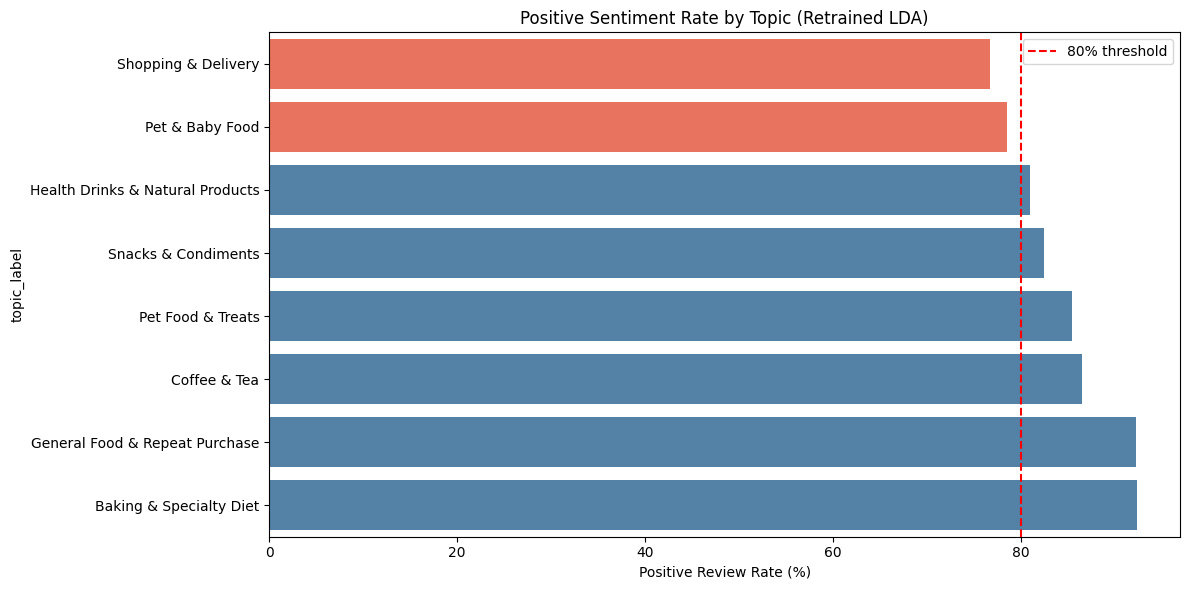

In [8]:
topic_sentiment = df2.groupby('topic_label')['sentiment'].agg(
    total='count',
    positive_count='sum'
)
topic_sentiment['positive_rate'] = (
    topic_sentiment['positive_count'] / topic_sentiment['total'] * 100
).round(2)
topic_sentiment['negative_rate'] = (
    100 - topic_sentiment['positive_rate']
).round(2)
topic_sentiment = topic_sentiment.sort_values('positive_rate')

print(topic_sentiment)

plt.figure(figsize=(12, 6))
colors = ['tomato' if x < 80 else 'steelblue'
          for x in topic_sentiment['positive_rate']]
sns.barplot(x=topic_sentiment['positive_rate'],
            y=topic_sentiment.index,
            palette=colors)
plt.title('Positive Sentiment Rate by Topic (Retrained LDA)')
plt.xlabel('Positive Review Rate (%)')
plt.axvline(x=80, color='red', linestyle='--', label='80% threshold')
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
df['refined_text'] = df['refined_text'].fillna('')
df = df[df['refined_text'].str.strip() != '']

vectorizer = CountVectorizer(
    max_features=15000,   # back to 15K
    min_df=5,
    max_df=0.90
)

doc_term_matrix = vectorizer.fit_transform(df['refined_text'])
print(f"Document-Term Matrix shape: {doc_term_matrix.shape}")
print(f"Matrix type: {type(doc_term_matrix)}")
print(f"Stored elements: {doc_term_matrix.nnz:,}")

Document-Term Matrix shape: (363821, 15000)
Matrix type: <class 'scipy.sparse._csr.csr_matrix'>
Stored elements: 9,438,421


In [10]:
from sklearn.decomposition import NMF

# Reuse the same vectorizer and matrix from LDA
# No need to refit — saves time and RAM

nmf_model = NMF(
    n_components=8,      # same number of topics as LDA
    random_state=42,
    max_iter=200
)

nmf_model.fit(doc_term_matrix)
print("NMF model trained successfully!")

NMF model trained successfully!


In [11]:
# Assign NMF topics to reviews
nmf_topic_labels = {
    0: 'Topic 1',  # update after seeing output
    1: 'Topic 2',
    2: 'Topic 3',
    3: 'Topic 4',
    4: 'Topic 5',
    5: 'Topic 6',
    6: 'Topic 7',
    7: 'Topic 8'
}

doc_topic_nmf = nmf_model.transform(doc_term_matrix)
df['nmf_topic'] = doc_topic_nmf.argmax(axis=1)
df['nmf_topic_label'] = df['nmf_topic'].map(nmf_topic_labels)

print(df['nmf_topic_label'].value_counts())

nmf_topic_label
Topic 8    110069
Topic 6     58700
Topic 5     52436
Topic 1     38359
Topic 7     35172
Topic 3     24909
Topic 4     22999
Topic 2     21177
Name: count, dtype: int64


In [12]:
print_topics(nmf_model, feature_names)


Topic 1:
lawn | tampa | tropic | substance | cautionary | washed | dishonest | surpise | dominant | ther | arrowhead | weigh | 220 | lengthwise | meld

Topic 2:
tartness | glucose | dishonest | approve | cornflake | bargin | kookaburra | blackbox | tampa | fage | washed | straight | bible | ointment | homeland

Topic 3:
chipolte | cornflake | dishonest | rhodesian | blackbox | astringency | straight | basmati | pitfall | craving | tampa | squeeze | tropic | jerk | lawn

Topic 4:
find | dietician | buttered | dominant | transit | lawn | exit | limited | dissapointed | immediatly | carrot | nuts | tropic | pencil | deen

Topic 5:
preservative | actor | nutrish | substance | grant | immediatly | prospect | washed | 220 | ointment | resident | flea | office | raving | muesli

Topic 6:
gather | tropic | pre | nutrish | ppm | dominant | microwaveable | weigh | pulled | flea | strawberry | biobag | lengthwise | evil | saltine

Topic 7:
fear | tropic | 220 | washed | saltine | exclaim | disho

In [13]:
nmf_topic_labels = {
    0: 'Snacks & Sweets',
    1: 'Tea & Herbal Drinks',
    2: 'Coffee',
    3: 'Pet Food',
    4: 'Health & Organic Products',
    5: 'Value & General Quality',
    6: 'Flavors & Condiments',
    7: 'Shopping Experience'
}

df['nmf_topic_label'] = df['nmf_topic'].map(nmf_topic_labels)
print(df['nmf_topic_label'].value_counts())

nmf_topic_label
Shopping Experience          110069
Value & General Quality       58700
Health & Organic Products     52436
Snacks & Sweets               38359
Flavors & Condiments          35172
Coffee                        24909
Pet Food                      22999
Tea & Herbal Drinks           21177
Name: count, dtype: int64


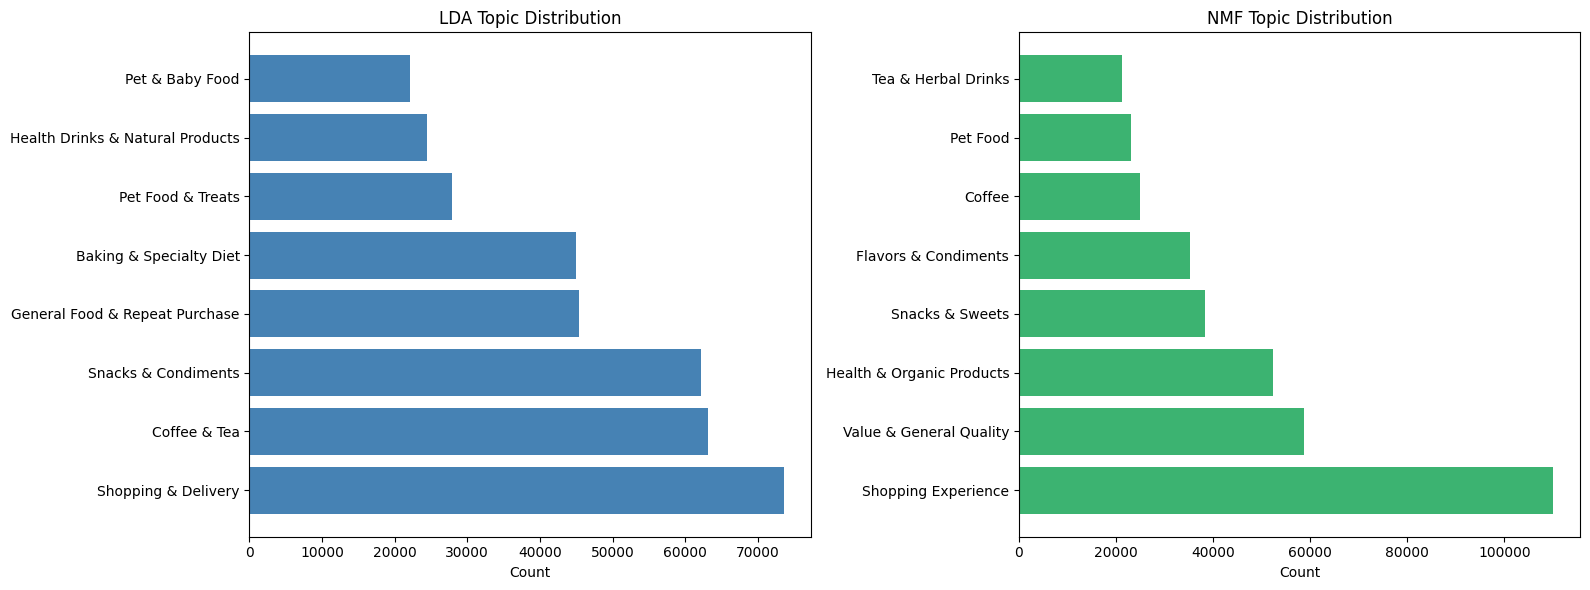

In [14]:
# Compare LDA vs NMF topic distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# LDA
lda_counts = df2['topic_label'].value_counts()
ax1.barh(lda_counts.index, lda_counts.values, color='steelblue')
ax1.set_title('LDA Topic Distribution')
ax1.set_xlabel('Count')

# NMF
nmf_counts = df['nmf_topic_label'].value_counts()
ax2.barh(nmf_counts.index, nmf_counts.values, color='mediumseagreen')
ax2.set_title('NMF Topic Distribution')
ax2.set_xlabel('Count')

plt.tight_layout()
plt.show()

                            total  positive_count  positive_rate  \
nmf_topic_label                                                    
Snacks & Sweets             38359           28735          74.91   
Health & Organic Products   52436           40420          77.08   
Pet Food                    22999           19241          83.66   
Coffee                      24909           20863          83.76   
Flavors & Condiments        35172           30044          85.42   
Shopping Experience        110069           94787          86.12   
Tea & Herbal Drinks         21177           18737          88.48   
Value & General Quality     58700           53927          91.87   

                           negative_rate  
nmf_topic_label                           
Snacks & Sweets                    25.09  
Health & Organic Products          22.92  
Pet Food                           16.34  
Coffee                             16.24  
Flavors & Condiments               14.58  
Shopping Experienc

C:\Users\pragy\AppData\Local\Temp\ipykernel_17952\1524657047.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=nmf_sentiment['positive_rate'],


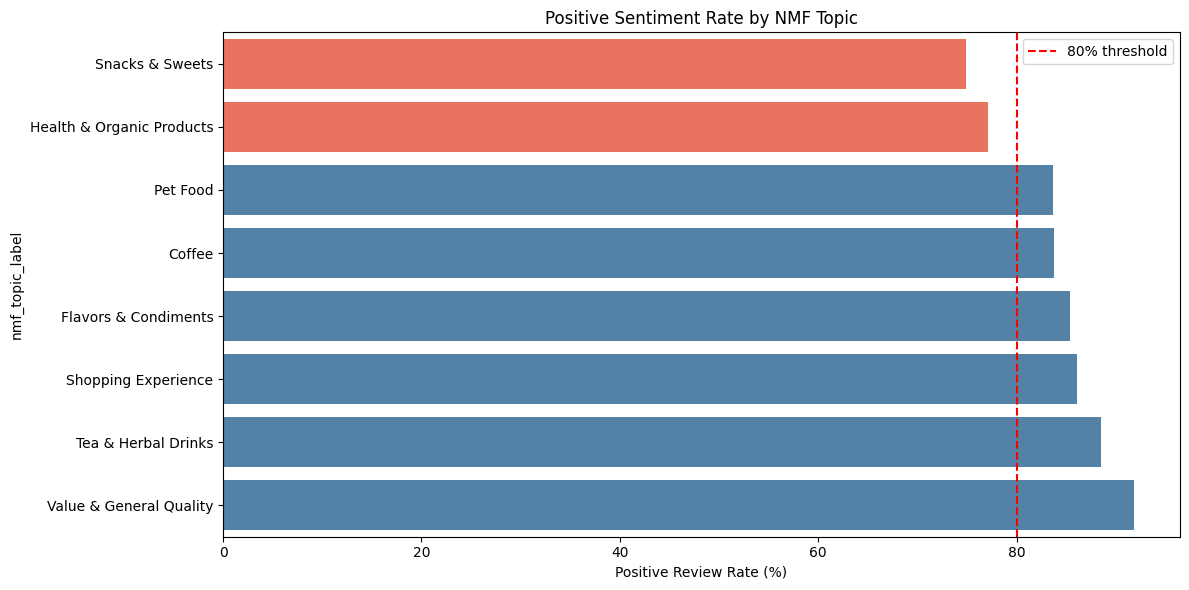

In [15]:
# NMF Topic vs Sentiment
nmf_sentiment = df.groupby('nmf_topic_label')['sentiment'].agg(
    total='count',
    positive_count='sum'
)
nmf_sentiment['positive_rate'] = (
    nmf_sentiment['positive_count'] / nmf_sentiment['total'] * 100
).round(2)
nmf_sentiment['negative_rate'] = (
    100 - nmf_sentiment['positive_rate']
).round(2)
nmf_sentiment = nmf_sentiment.sort_values('positive_rate')

print(nmf_sentiment)

plt.figure(figsize=(12, 6))
colors = ['tomato' if x < 80 else 'steelblue' 
          for x in nmf_sentiment['positive_rate']]
sns.barplot(x=nmf_sentiment['positive_rate'],
            y=nmf_sentiment.index,
            palette=colors)
plt.title('Positive Sentiment Rate by NMF Topic')
plt.xlabel('Positive Review Rate (%)')
plt.axvline(x=80, color='red', linestyle='--', label='80% threshold')
plt.legend()
plt.tight_layout()
plt.show()

Why They Don't Contradict Each Other
Think of it like two different lenses on the same data:
LDANMFFound WHAT went wrong (packaging)Found WHO is unhappy (health buyers)Topic = complaint typeTopic = customer segmentProbabilistic — allows overlapAdditive — forces clean separation
They're not saying different things — they're saying complementary things.

What This Chart Communicates
The red bars tell the story instantly:

Packaging & Product Issues — 4th largest topic by volume AND the worst sentiment. High volume + high negativity = biggest business problem
Pantry & Cooking Ingredients — smaller volume but still flagged red

The combination of both charts together is powerful:

Chart 6 shows how bad the sentiment is per topic
Chart 7 shows how many reviews each topic has

Together they prioritize where a business should focus:

Packaging first (large volume + worst sentiment), Pantry second

C:\Users\pragy\AppData\Local\Temp\ipykernel_17952\2573572880.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=nmf_counts.values, y=nmf_counts.index, palette=colors)


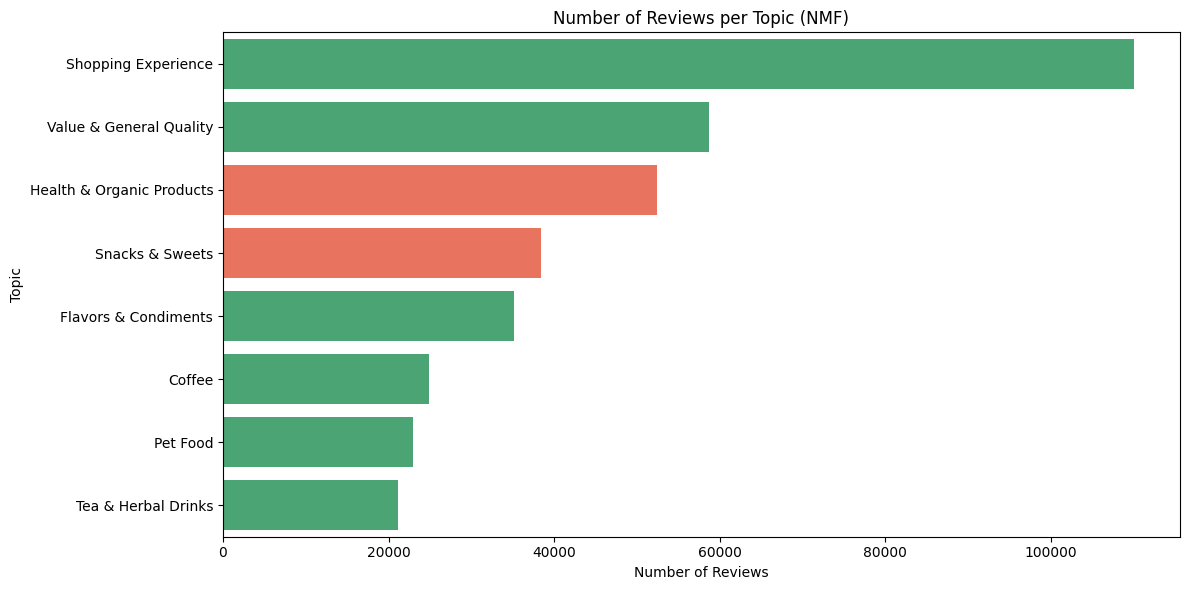

In [16]:
plt.figure(figsize=(12, 6))
nmf_counts = df['nmf_topic_label'].value_counts()
colors = ['tomato' if label in ['Snacks & Sweets', 
          'Health & Organic Products'] else 'mediumseagreen' 
          for label in nmf_counts.index]

sns.barplot(x=nmf_counts.values, y=nmf_counts.index, palette=colors)
plt.title('Number of Reviews per Topic (NMF)')
plt.xlabel('Number of Reviews')
plt.ylabel('Topic')
plt.tight_layout()
plt.show()

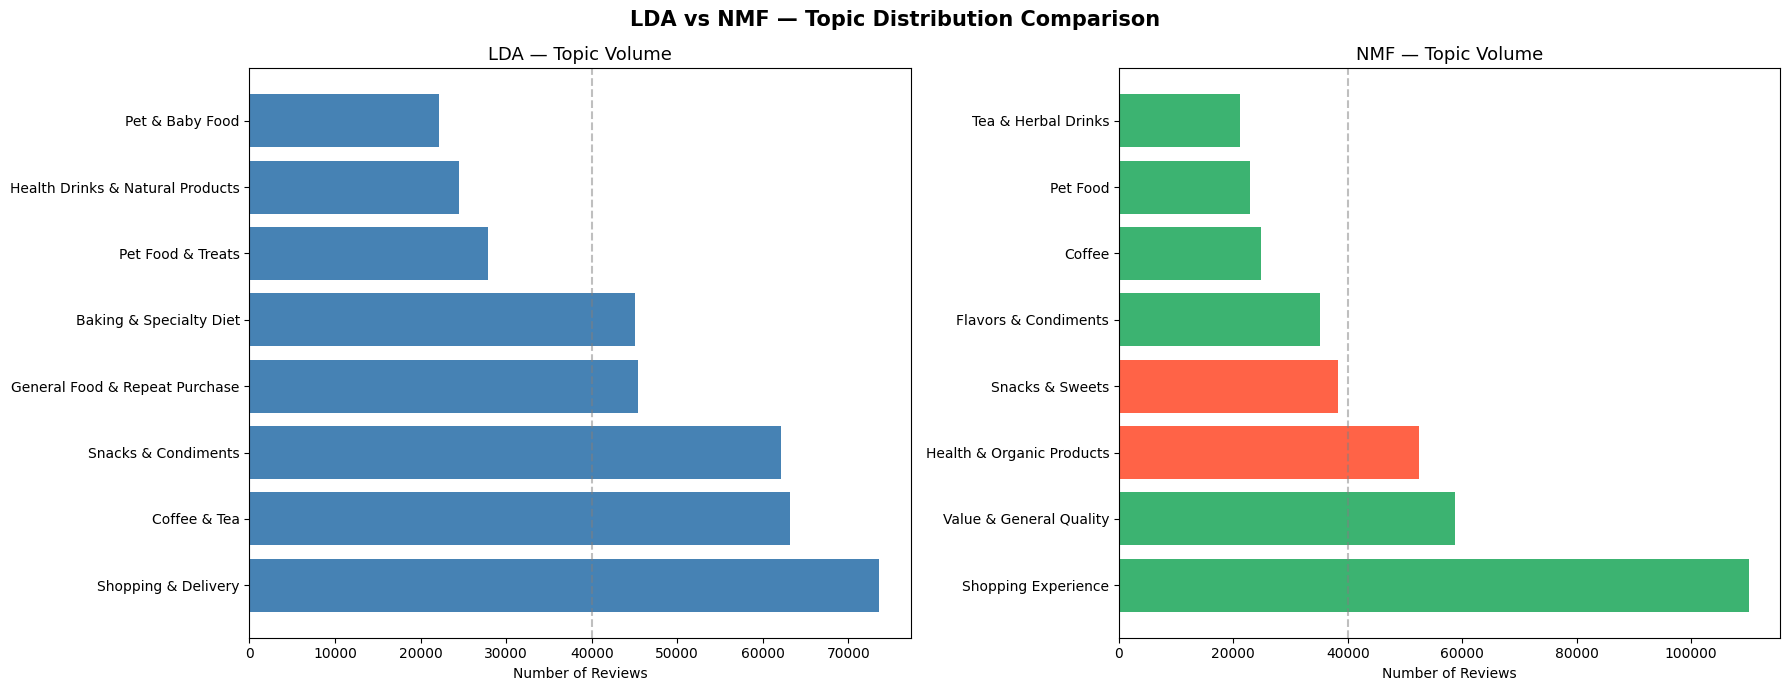

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# LDA
lda_counts = df2['topic_label'].value_counts()
lda_colors = ['tomato' if label in ['Packaging & Product Issues',
              'Pantry & Cooking Ingredients'] else 'steelblue'
              for label in lda_counts.index]
ax1.barh(lda_counts.index, lda_counts.values, color=lda_colors)
ax1.set_title('LDA — Topic Volume', fontsize=13)
ax1.set_xlabel('Number of Reviews')
ax1.axvline(x=40000, color='gray', linestyle='--', alpha=0.5)

# NMF
nmf_counts = df['nmf_topic_label'].value_counts()
nmf_colors = ['tomato' if label in ['Snacks & Sweets',
              'Health & Organic Products'] else 'mediumseagreen'
              for label in nmf_counts.index]
ax2.barh(nmf_counts.index, nmf_counts.values, color=nmf_colors)
ax2.set_title('NMF — Topic Volume', fontsize=13)
ax2.set_xlabel('Number of Reviews')
ax2.axvline(x=40000, color='gray', linestyle='--', alpha=0.5)

plt.suptitle('LDA vs NMF — Topic Distribution Comparison', 
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

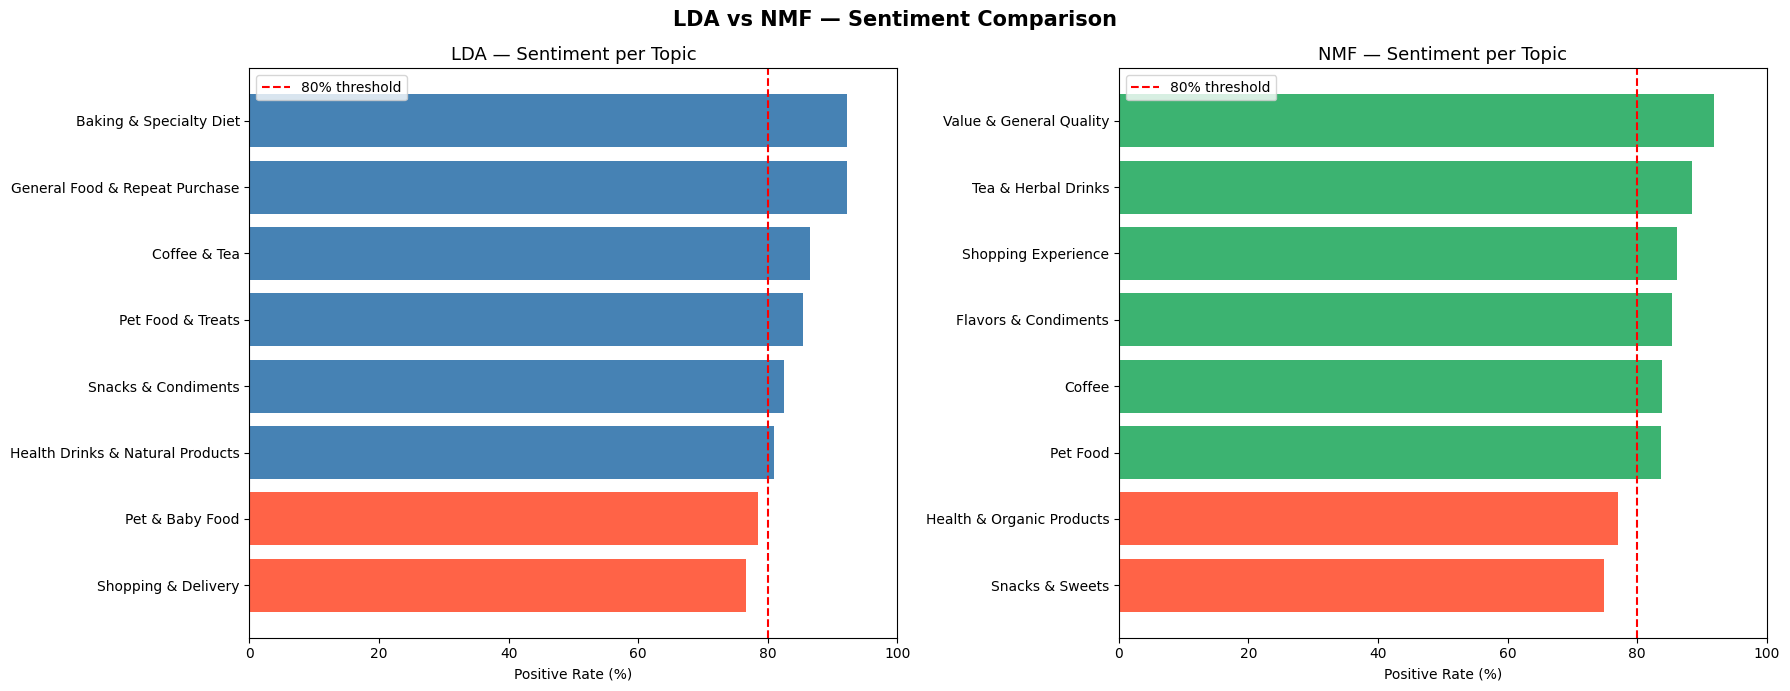

In [18]:
# Prepare LDA sentiment data
lda_sent = df2.groupby('topic_label')['sentiment'].agg(
    total='count', positive_count='sum'
)
lda_sent['positive_rate'] = (
    lda_sent['positive_count'] / lda_sent['total'] * 100
).round(2)
lda_sent = lda_sent.sort_values('positive_rate')

# Prepare NMF sentiment data
nmf_sent = df.groupby('nmf_topic_label')['sentiment'].agg(
    total='count', positive_count='sum'
)
nmf_sent['positive_rate'] = (
    nmf_sent['positive_count'] / nmf_sent['total'] * 100
).round(2)
nmf_sent = nmf_sent.sort_values('positive_rate')

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# LDA sentiment
lda_colors = ['tomato' if x < 80 else 'steelblue' 
              for x in lda_sent['positive_rate']]
ax1.barh(lda_sent.index, lda_sent['positive_rate'], color=lda_colors)
ax1.axvline(x=80, color='red', linestyle='--', label='80% threshold')
ax1.set_title('LDA — Sentiment per Topic', fontsize=13)
ax1.set_xlabel('Positive Rate (%)')
ax1.set_xlim(0, 100)
ax1.legend()

# NMF sentiment
nmf_colors = ['tomato' if x < 80 else 'mediumseagreen'
              for x in nmf_sent['positive_rate']]
ax2.barh(nmf_sent.index, nmf_sent['positive_rate'], color=nmf_colors)
ax2.axvline(x=80, color='red', linestyle='--', label='80% threshold')
ax2.set_title('NMF — Sentiment per Topic', fontsize=13)
ax2.set_xlabel('Positive Rate (%)')
ax2.set_xlim(0, 100)
ax2.legend()

plt.suptitle('LDA vs NMF — Sentiment Comparison', 
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [19]:
# Merge LDA and NMF sentiment rates for comparison
lda_sent_reset = lda_sent[['positive_rate']].reset_index()
lda_sent_reset.columns = ['Topic', 'LDA_positive_rate']

nmf_sent_reset = nmf_sent[['positive_rate']].reset_index()
nmf_sent_reset.columns = ['Topic', 'NMF_positive_rate']

# Overall averages
print("=== MODEL AGREEMENT SUMMARY ===")
print(f"\nLDA Average Positive Rate: {lda_sent['positive_rate'].mean():.2f}%")
print(f"NMF Average Positive Rate: {nmf_sent['positive_rate'].mean():.2f}%")

print("\n=== LDA PROBLEM TOPICS (<80%) ===")
print(lda_sent[lda_sent['positive_rate'] < 80][['positive_rate']])

print("\n=== NMF PROBLEM TOPICS (<80%) ===")
print(nmf_sent[nmf_sent['positive_rate'] < 80][['positive_rate']])

print("\n=== TOPICS BOTH MODELS FLAG AS PROBLEMS ===")
lda_problems = set(lda_sent[lda_sent['positive_rate'] < 80].index)
nmf_problems = set(nmf_sent[nmf_sent['positive_rate'] < 80].index)
print("LDA flags:", lda_problems)
print("NMF flags:", nmf_problems)

=== MODEL AGREEMENT SUMMARY ===

LDA Average Positive Rate: 84.38%
NMF Average Positive Rate: 83.91%

=== LDA PROBLEM TOPICS (<80%) ===
                     positive_rate
topic_label                       
Shopping & Delivery          76.70
Pet & Baby Food              78.51

=== NMF PROBLEM TOPICS (<80%) ===
                           positive_rate
nmf_topic_label                         
Snacks & Sweets                    74.91
Health & Organic Products          77.08

=== TOPICS BOTH MODELS FLAG AS PROBLEMS ===
LDA flags: {'Pet & Baby Food', 'Shopping & Delivery'}
NMF flags: {'Snacks & Sweets', 'Health & Organic Products'}


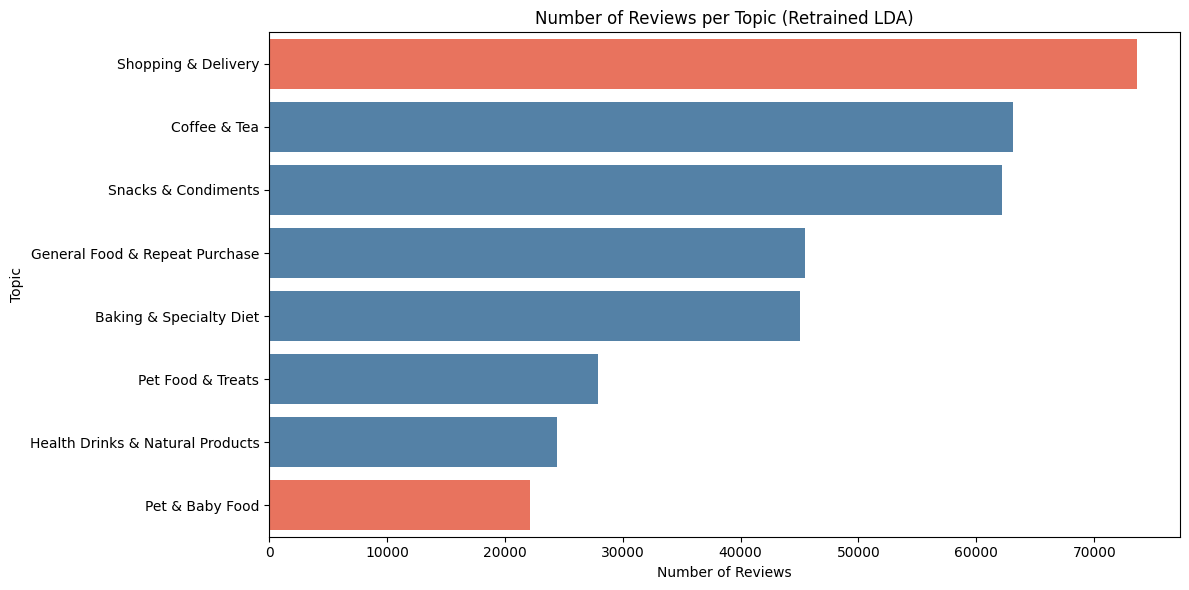

In [20]:
plt.figure(figsize=(12, 6))
topic_counts = df2['topic_label'].value_counts()
colors = ['tomato' if label in ['Shopping & Delivery', 
          'Pet & Baby Food'] else 'steelblue' 
          for label in topic_counts.index]

sns.barplot(x=topic_counts.values, y=topic_counts.index,
            hue=topic_counts.index,
            legend=False,
            palette=colors)
plt.title('Number of Reviews per Topic (Retrained LDA)')
plt.xlabel('Number of Reviews')
plt.ylabel('Topic')
plt.tight_layout()
plt.show()

In [21]:
print("df columns:", df.columns.tolist())
print("df shape:", df.shape)
print("\ndf2 columns:", df2.columns.tolist())  
print("df2 shape:", df2.shape)

df columns: ['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text', 'review_length', 'helpfulness_ratio', 'Year', 'refined_text', 'sentiment', 'vader_score', 'vader_label', 'nmf_topic', 'nmf_topic_label']
df shape: (363821, 19)

df2 columns: ['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text', 'review_length', 'helpfulness_ratio', 'Year', 'lemmatized_text', 'sentiment', 'dominant_topic', 'topic_label']
df2 shape: (363822, 17)


In [22]:
# Merge NMF topics from df into df2 on Id
df_master = df2.merge(
    df[['Id', 'nmf_topic', 'nmf_topic_label', 
        'vader_score', 'vader_label', 'refined_text']],
    on='Id',
    how='left'
)

print(f"Master shape: {df_master.shape}")
print(f"Columns: {df_master.columns.tolist()}")

Master shape: (363822, 22)
Columns: ['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text', 'review_length', 'helpfulness_ratio', 'Year', 'lemmatized_text', 'sentiment', 'dominant_topic', 'topic_label', 'nmf_topic', 'nmf_topic_label', 'vader_score', 'vader_label', 'refined_text']


In [23]:
df_master.to_csv('Reviews_topics.csv', index=False)
print("Master dataframe saved!")

Master dataframe saved!
